# Course 1 — Linear Regression

Concepts: univariate & multivariate regression, normal equation, scikit-learn, feature scaling.


In [1]:
import sys
from pathlib import Path
# Add repository root to sys.path dynamically
project_root = Path(".").resolve()
while project_root.name and not (project_root / "utils").is_dir():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from utils.helpers import make_linear_data, plot_regression_line


## 1. Univariate Linear Regression
Closed-form solution (Normal Equation) vs. Scikit-Learn `LinearRegression`.


[Normal Equation] y = 2.008x + 0.974
[sklearn] y = 2.008x + 0.974


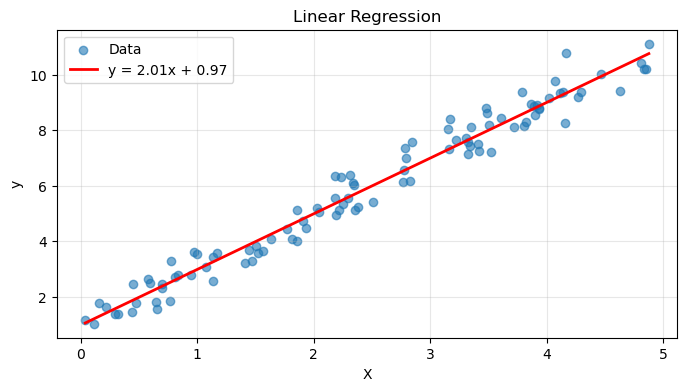

In [2]:
X, y = make_linear_data(w=2.0, b=1.0, n=100, noise=0.5)

# Closed-form (Normal Equation): w = (X^T X)^{-1} X^T y
X_b = np.c_[np.ones((X.shape[0], 1)), X]  # add bias term (x0 = 1)
w_closed = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
b_closed, w_closed = w_closed[0], w_closed[1]
print(f"[Normal Equation] y = {w_closed:.3f}x + {b_closed:.3f}")

# Sklearn
model = LinearRegression()
model.fit(X, y)
print(f"[sklearn] y = {model.coef_[0]:.3f}x + {model.intercept_:.3f}")

plot_regression_line(X, y, model.coef_[0], model.intercept_)


## 2. Multivariate Linear Regression
Linear regression with multiple input features ($x_1, x_2, x_3$).


In [3]:
print("── Multivariate Regression ──")
rng = np.random.default_rng(42)
X_multi = rng.uniform(0, 5, size=(200, 3))
true_w = np.array([1.5, -0.8, 2.3])
true_b = 0.5
y_multi = X_multi @ true_w + true_b + rng.normal(0, 0.3, size=200)

X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)
y_pred = model_multi.predict(X_test)

print(f"True weights: {true_w}")
print(f"Learned weights: {model_multi.coef_}")
print(f"True bias: {true_b:.2f}")
print(f"Learned bias: {model_multi.intercept_:.2f}")
print(f"Test MSE: {mean_squared_error(y_test, y_pred):.4f}")


── Multivariate Regression ──
True weights: [ 1.5 -0.8  2.3]
Learned weights: [ 1.5141912  -0.80244125  2.29209619]
True bias: 0.50
Learned bias: 0.46
Test MSE: 0.0895


## 3. Feature Scaling (Standardization)
Standardizing features so mean = 0 and standard deviation = 1.


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Mean after scaling: {X_train_scaled.mean(axis=0).round(4)}")
print(f"Std after scaling: {X_train_scaled.std(axis=0).round(4)}")


Mean after scaling: [-0. -0. -0.]
Std after scaling: [1. 1. 1.]


## Key Takeaways


In [5]:
print("""
╔══ Key Takeaways ───────────────────────────────────────────────╗
║ • Linear Regression: models relationships with continuous target║
║ • Normal Equation: analytical closed-form solution             ║
║   → w = (X^T X)^(-1) X^T y (slow for large feature counts)     ║
║ • Gradient Descent: iterative optimization alternative          ║
║ • Feature Scaling: essential for gradient descent convergence   ║
║ • Evaluation: Mean Squared Error (MSE) measures prediction loss║
╚════════════════════════════════════════════════════════════════╝
""")



╔══ Key Takeaways ───────────────────────────────────────────────╗
║ • Linear Regression: models relationships with continuous target║
║ • Normal Equation: analytical closed-form solution             ║
║   → w = (X^T X)^(-1) X^T y (slow for large feature counts)     ║
║ • Gradient Descent: iterative optimization alternative          ║
║ • Feature Scaling: essential for gradient descent convergence   ║
║ • Evaluation: Mean Squared Error (MSE) measures prediction loss║
╚════════════════════════════════════════════════════════════════╝

